In [1]:
import numpy as np
import matplotlib.pyplot as plt
import Comm as com
import math

# Test of the transmission chain #

In [2]:
# Flat fading channel taps
a = 1
tau = 0

# Parameters
B = 100e6
osr = 8
Fs = B * osr
Ts = 1 / Fs
alpha = 0.5

# Channel
span = 80 # Number of symbols
L = span * osr + 1
t_filter = np.linspace(-span/(2*B), span/(2*B), L)
g = com.RRC(t_filter, tau, B, alpha) * a

# Matched filter
g_matched = g

Eg = 1
print("Symbol energy (Eg):", Eg)

corr = np.correlate(g, g_matched, mode='full') / osr
Eg_corr = np.sum(corr**2) * 1 / osr
print("Correlation energy:", Eg_corr)

rc = com.RC(t_filter, tau, B, alpha)
print("RC filter energy:", np.sum(rc**2) * 1 / osr)

Symbol energy (Eg): 1
Correlation energy: 0.875000004620452
RC filter energy: 0.8749999999009295


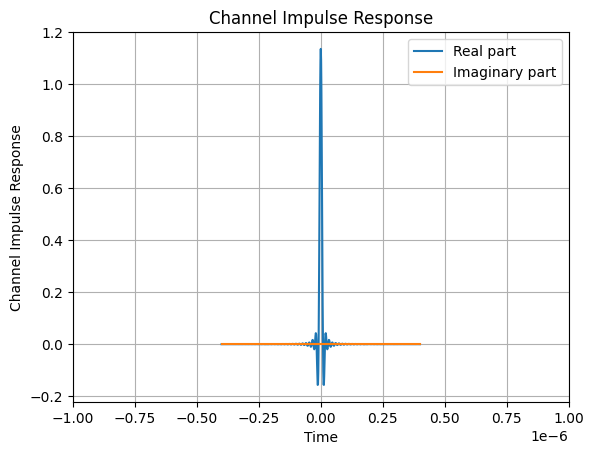

In [3]:
plt.figure()
plt.plot(t_filter, g.real, label='Real part')
plt.plot(t_filter, g.imag, label='Imaginary part')
plt.xlim(-1e-6, 1e-6)
plt.xlabel('Time')
plt.ylabel('Channel Impulse Response')
plt.title('Channel Impulse Response')
plt.grid()
plt.legend()
plt.show()

### Generating random bits ###


In [4]:
def bits_to_qpsk(bits):

    symbols = (2*bits[0::2] - 1) + 1j*(2*bits[1::2] - 1)
    # Normalize the power of the symbols to 1
    symbols /= np.sqrt(2)

    return symbols

def qpsk_to_bits(symbols):

    bits = np.zeros(2*len(symbols), dtype=int)
    bits[0::2] = (np.real(symbols) > 0).astype(int)
    bits[1::2] = (np.imag(symbols) > 0).astype(int)

    return bits



In [5]:
bits = np.random.randint(0, 2, 10)
print("Random bits:", bits)

symbols = bits_to_qpsk(bits)
print("QPSK symbols:", symbols)

bits_estimated = qpsk_to_bits(symbols)
print("Estimated bits:", bits_estimated)

Random bits: [1 1 0 0 0 1 1 0 0 1]
QPSK symbols: [ 0.70710678+0.70710678j -0.70710678-0.70710678j -0.70710678+0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j]
Estimated bits: [1 1 0 0 0 1 1 0 0 1]


In [6]:
N = 100000
no = 1
sigma_n = 2*no * osr
noise = np.sqrt(sigma_n/2) * (np.random.randn(N) + 1j*np.random.randn(N))
noise_filtered = np.convolve(noise, g_matched, mode='full') / osr 
noise_filtered = noise_filtered[::osr]

noise_power = np.mean(np.abs(noise)**2/osr)
noise_filtered_power = np.mean(np.abs(noise_filtered)**2)
print("Noise power:", noise_power)
print("Filtered noise power:", noise_filtered_power)


Noise power: 1.9980979439903406
Filtered noise power: 1.9779180163353562


In [7]:
snr_db = np.arange(0, 9, 1)
no  = 1 / (2*10**(snr_db/10))

bers = np.zeros(len(snr_db))

for i in range(len(snr_db)):
    sigma_n = 2*no[i] * osr
    for iter in range(100):
        num_bits = 1000
        bits = np.random.randint(0, 2, num_bits)

        # Modulation
        symbols = bits_to_qpsk(bits)
        x = np.zeros(len(symbols)*osr, dtype=complex)
        x[::osr] = symbols

        # Transmission through the channel
        y = np.convolve(x, g, mode='full')

        # Add noise
        noise = np.sqrt(sigma_n/2) * (np.random.randn(len(y)) + 1j*np.random.randn(len(y)))
        y_noisy = y + noise

        # Matched filtering
        y_matched = np.convolve(y_noisy, g_matched, mode='full') / osr

        # Synchronization (assuming perfect synchronization for simplicity)
        y_sync = y_matched[L-1:L-1+len(symbols)*osr:osr]

        # Demodulation
        bits_estimated = qpsk_to_bits(y_sync)

        # BER calculation
        ber = np.mean(bits != bits_estimated)
        bers[i] += ber

    print(f"SNR: {snr_db[i]} dB, BER: {bers[i]/100}")

# Average the BERs over the simulations
bers /= 100
print("BERs:", bers)

SNR: 0 dB, BER: 0.15955000000000003
SNR: 1 dB, BER: 0.13004
SNR: 2 dB, BER: 0.1037500000000001
SNR: 3 dB, BER: 0.08066
SNR: 4 dB, BER: 0.05632000000000003
SNR: 5 dB, BER: 0.03750999999999999
SNR: 6 dB, BER: 0.02346999999999999
SNR: 7 dB, BER: 0.012229999999999994
SNR: 8 dB, BER: 0.006480000000000005
BERs: [0.15955 0.13004 0.10375 0.08066 0.05632 0.03751 0.02347 0.01223 0.00648]


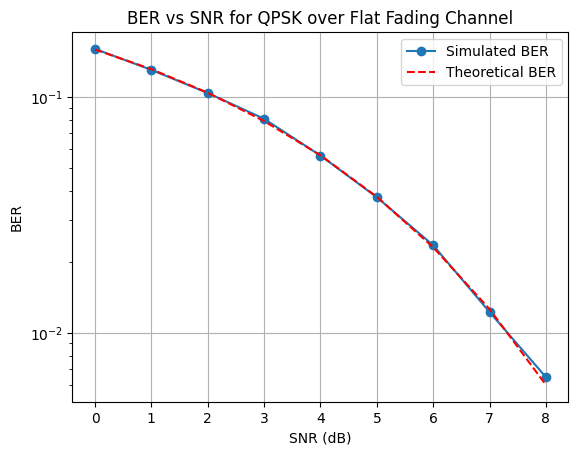

In [8]:
theoretical_ber = np.array([0.5 * math.erfc(np.sqrt(10**(snr_db[i]/10)/2)) for i in range(len(snr_db))])

plt.figure()
plt.semilogy(snr_db, bers, 'o-', label='Simulated BER')
plt.semilogy(snr_db, theoretical_ber, 'r--', label='Theoretical BER')
plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.title('BER vs SNR for QPSK over Flat Fading Channel')
plt.grid()
plt.legend()
plt.show()

799 480


c:\Users\louis\OneDrive\Documents\Memoire\RayTracing\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\louis\OneDrive\Documents\Memoire\RayTracing\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


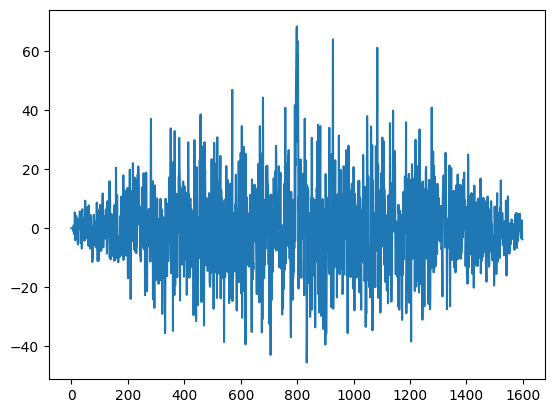

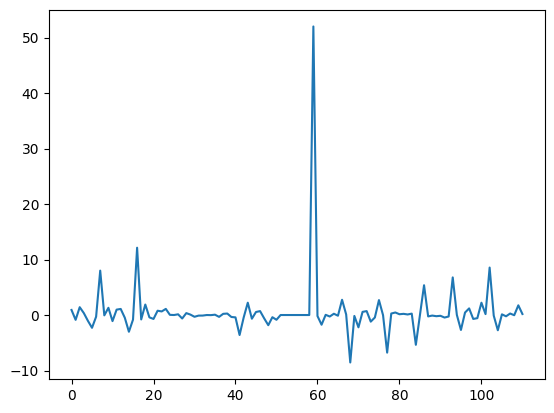

In [9]:
Lcir = 8
pilot_length = 52
pilot_seq = com.zadoff_chu_seq(23, pilot_length)
prefixed_pilot_length = pilot_length + Lcir # Account for cyclic prefix
prefixed_pilot_seq = np.concatenate((pilot_seq[-Lcir:], pilot_seq)) # Add cyclic prefix
x = np.zeros(prefixed_pilot_length*osr, dtype=complex)
x[:prefixed_pilot_length*osr:osr] = prefixed_pilot_seq

y = np.convolve(x, g, mode='full')
sigma_n = 1 * osr
y += np.sqrt(sigma_n/2) * (np.random.randn(len(y)) + 1j*np.random.randn(len(y)))



cross_corr = np.correlate(y, x, mode='full')
print(np.argmax(cross_corr), len(prefixed_pilot_seq)*osr)

plt.figure()
plt.plot(cross_corr)
plt.show()

cross_corr = np.correlate(prefixed_pilot_seq, pilot_seq, mode='full')
plt.figure()
plt.plot(cross_corr)
plt.show()

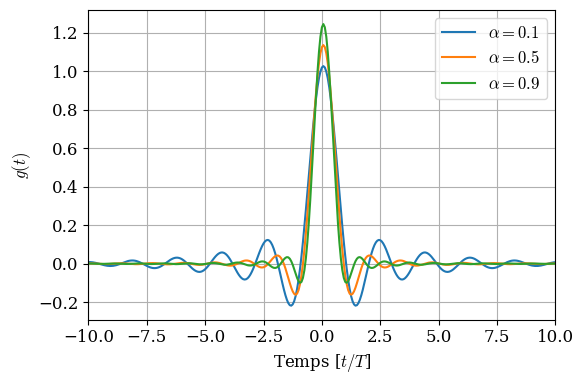

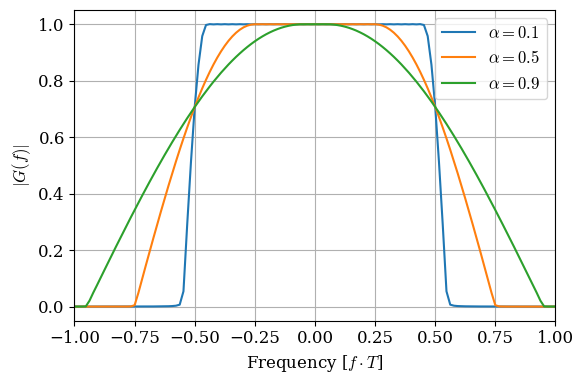

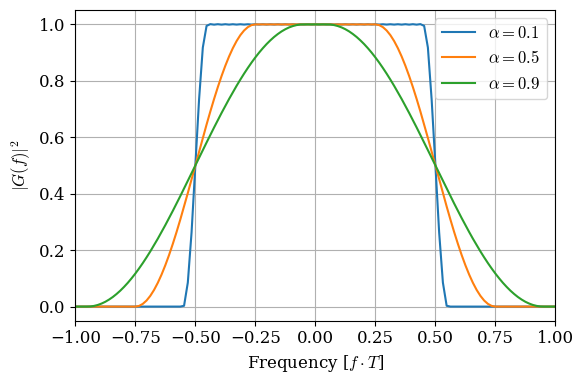

In [31]:
plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",  # This gives the LaTeX look to math text
    "axes.edgecolor": "black", # Black bounding box
    "axes.linewidth": 0.8
})

B = 1
osr = 16
Fs = B * osr
Ts = 1 / Fs

alpha = [0.1, 0.5, 0.9]
symbols = 64
samples = symbols * osr
t = np.arange(-samples//2, samples//2) * Ts


alphas = [0.1, 0.5, 0.9]

fig, ax = plt.subplots(figsize=(6, 4))

for i, alpha in enumerate(alphas):
    g = com.RRC(t, Ts, B, alpha)
    
    # Trace domaine temporel
    ax.plot(t, g, label=f'$\\alpha={alpha}$')
    ax.set_xlabel('Temps [$t/T$]')
    ax.set_ylabel('$g(t)$')
    ax.set_xlim(-10, 10)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig('RRC_time_domain.pdf')
plt.show()


fig, ax = plt.subplots(figsize=(6, 4))

for i, alpha in enumerate(alphas):
    # Trace domaine fréquentiel
    # Le zero-padding augmente la résolution spectrale de notre FFT

    g = com.RRC(t, Ts, B, alpha)
    
    G = np.fft.fftshift(np.fft.fft(g)) / osr
    freqs = np.linspace(-osr//2, osr//2, len(G), endpoint=False)

    
    G_mag = np.abs(G)
    
    ax.plot(freqs, G_mag, label=f'$\\alpha={alpha}$')
    ax.set_xlabel('Frequency [$f \\cdot T$]')
    ax.set_ylabel('$|G(f)|$')
    ax.set_xlim(-1, 1) # Force l'axe de -1 à 1
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig('RRC_frequency_domain.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

for i, alpha in enumerate(alphas):
    # Trace domaine fréquentiel
    # Le zero-padding augmente la résolution spectrale de notre FFT

    g = com.RRC(t, Ts, B, alpha)
    
    G = np.fft.fftshift(np.fft.fft(g)) / osr
    freqs = np.linspace(-osr//2, osr//2, len(G), endpoint=False)

    
    G_mag_2 = np.abs(G)**2
    
    ax.plot(freqs, G_mag_2, label=f'$\\alpha={alpha}$')
    ax.set_xlabel('Frequency [$f \\cdot T$]')
    ax.set_ylabel('$|G(f)|^2$')
    ax.set_xlim(-1, 1) # Force l'axe de -1 à 1
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig('RC_frequency_domain.pdf')
plt.show()